In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


In [2]:
DB_PATH = Path("../olist.db")
ORDER_STATUS_FILTER = "delivered"

In [3]:
with sqlite3.connect(DB_PATH) as conn:
    fact_orders = pd.read_sql(
        """
        SELECT *
        FROM fact_orders
        WHERE order_status = ?
        """,
        conn,
        params=(ORDER_STATUS_FILTER,),
        parse_dates=["order_purchase_ts", "order_purchase_date"],
    )

    fact_items = pd.read_sql(
        """
        SELECT *
        FROM fact_order_items
        WHERE order_status = ?
        """,
        conn,
        params=(ORDER_STATUS_FILTER,),
        parse_dates=["order_purchase_ts", "shipping_limit_date"],
    )


In [4]:
fact_orders.shape, fact_items.shape


((96478, 18), (110197, 17))

In [5]:
fact_orders.dtypes


order_id                        object
customer_id                     object
customer_unique_id              object
order_status                    object
order_purchase_ts       datetime64[ns]
order_purchase_date     datetime64[ns]
order_purchase_ym               object
customer_city                   object
customer_state                  object
n_items                          int64
n_products                       int64
gross_items_value              float64
total_freight_value            float64
total_payment_value            float64
max_installments               float64
n_payment_records              float64
primary_payment_type            object
avg_review_score               float64
dtype: object

In [6]:
(
    fact_orders
    .isna()
    .mean()
    .sort_values(ascending=False)
)


avg_review_score        0.006696
primary_payment_type    0.000819
max_installments        0.000010
total_payment_value     0.000010
n_payment_records       0.000010
order_id                0.000000
customer_id             0.000000
customer_unique_id      0.000000
order_purchase_ts       0.000000
order_status            0.000000
n_items                 0.000000
customer_state          0.000000
customer_city           0.000000
order_purchase_ym       0.000000
order_purchase_date     0.000000
total_freight_value     0.000000
n_products              0.000000
gross_items_value       0.000000
dtype: float64

In [7]:
assert fact_orders["order_id"].is_unique, "Duplicate order_id found"
assert fact_items[["order_id", "order_item_id"]].duplicated().sum() == 0


In [8]:
fact_orders["order_purchase_date"].min(), fact_orders["order_purchase_date"].max()


(Timestamp('2016-09-15 00:00:00'), Timestamp('2018-08-29 00:00:00'))

In [9]:
fact_orders["total_payment_value"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


count    96477.000000
mean       159.856357
std        218.813144
min          9.590000
1%          22.380000
5%          32.380000
50%        105.280000
95%        446.312000
99%       1052.391200
max      13664.080000
Name: total_payment_value, dtype: float64

In [10]:
negative_payments = fact_orders.loc[
    fact_orders["total_payment_value"] < 0,
    ["order_id", "customer_unique_id", "total_payment_value"]
]

negative_payments.shape


(0, 3)

In [11]:
# Enforce non-negative monetary values as a business rule
# (no anomalies observed after filtering to delivered orders)
fact_orders["total_payment_value"] = fact_orders["total_payment_value"].clip(lower=0)


In [12]:
fact_orders["total_payment_value"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])


count    96477.000000
mean       159.856357
std        218.813144
min          9.590000
50%        105.280000
75%        176.330000
90%        305.974000
95%        446.312000
99%       1052.391200
max      13664.080000
Name: total_payment_value, dtype: float64

In [13]:
monthly_revenue = (
    fact_orders
    .groupby("order_purchase_ym", as_index=False)
    .agg(revenue=("total_payment_value", "sum"))
)

monthly_revenue["order_purchase_ym"] = pd.to_datetime(monthly_revenue["order_purchase_ym"])
monthly_revenue.head()


,order_purchase_ym,revenue
0,2016-09-01,0.00
1,2016-10-01,46566.71
2,2016-12-01,19.62
3,2017-01-01,127545.67
4,2017-02-01,271298.65


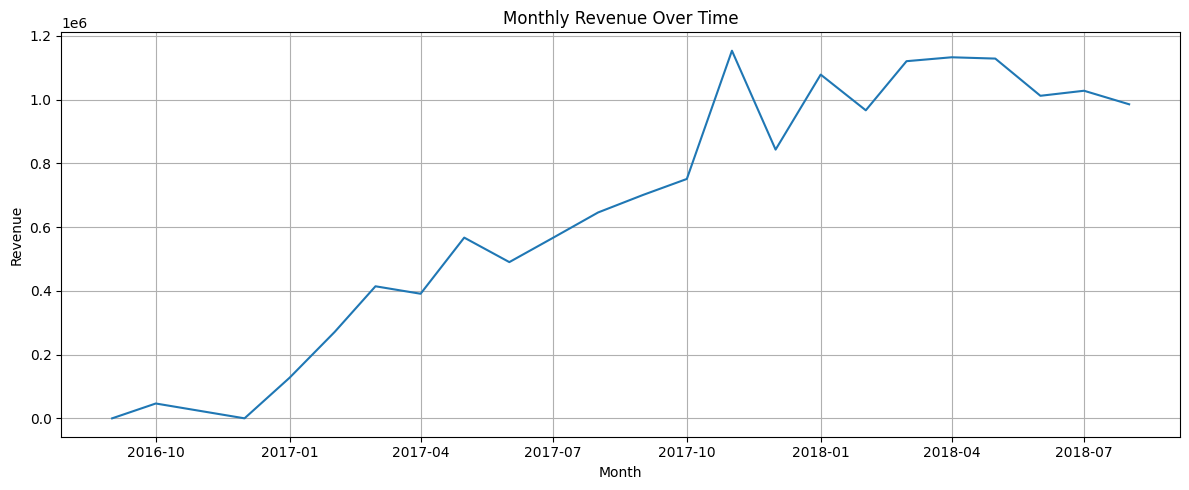

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["order_purchase_ym"], monthly_revenue["revenue"])
plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
monthly_orders = (
    fact_orders
    .groupby("order_purchase_ym", as_index=False)
    .agg(orders=("order_id", "nunique"))
)

monthly_orders["order_purchase_ym"] = pd.to_datetime(monthly_orders["order_purchase_ym"])

monthly_orders.head()


,order_purchase_ym,orders
0,2016-09-01,1
1,2016-10-01,265
2,2016-12-01,1
3,2017-01-01,750
4,2017-02-01,1653


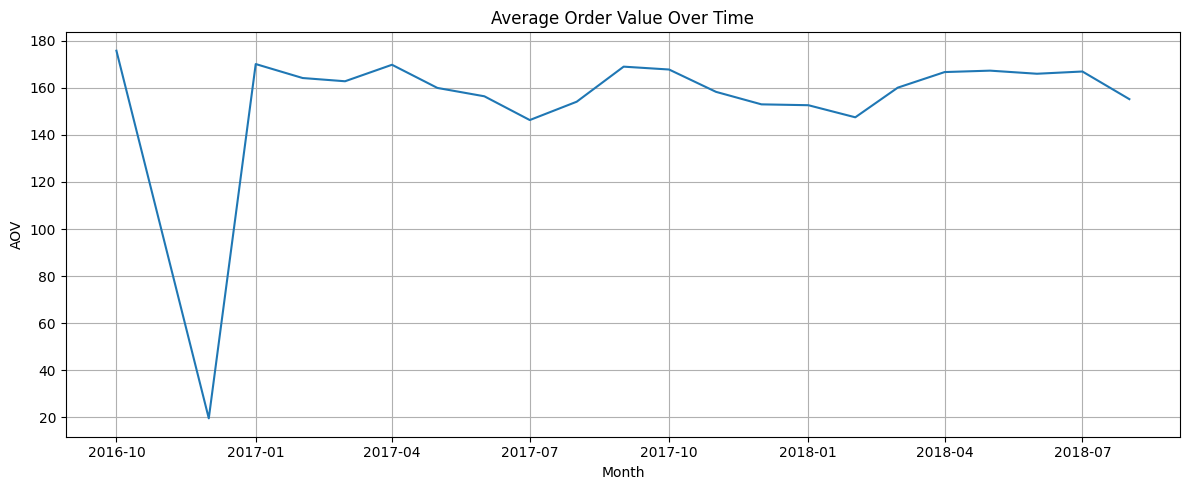

In [16]:
monthly_aov = (
    fact_orders
    .groupby("order_purchase_ym", as_index=False)
    .agg(aov=("total_payment_value", "mean"))
)

monthly_aov["order_purchase_ym"] = pd.to_datetime(monthly_aov["order_purchase_ym"])

plt.figure(figsize=(12, 5))
plt.plot(monthly_aov["order_purchase_ym"], monthly_aov["aov"])
plt.title("Average Order Value Over Time")
plt.xlabel("Month")
plt.ylabel("AOV")
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
category_revenue = (
    fact_items
    .groupby("product_category_name_english", as_index=False)
    .agg(revenue=("price", "sum"))
    .sort_values("revenue", ascending=False)
)

category_revenue.head(10)


,product_category_name_english,revenue
43,health_beauty,1233131.72
70,watches_gifts,1166176.98
7,bed_bath_table,1023434.76
65,sports_leisure,954852.55
15,computers_accessories,888724.61
39,furniture_decor,711927.69
49,housewares,615628.69
20,cool_stuff,610204.10
5,auto,578966.65
69,toys,471286.48


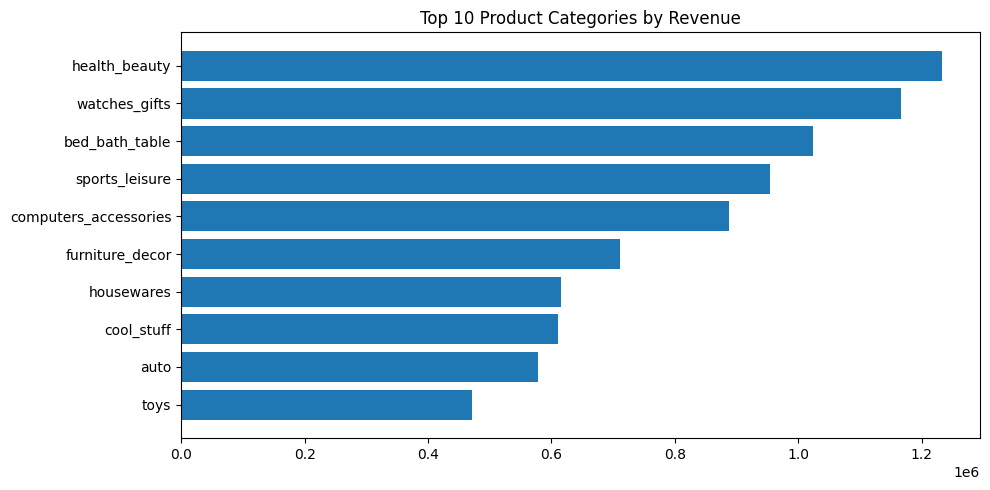

In [18]:
top_categories = category_revenue.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_categories["product_category_name_english"], top_categories["revenue"])
plt.gca().invert_yaxis()
plt.title("Top 10 Product Categories by Revenue")
plt.tight_layout()
plt.show()


In [19]:
state_revenue = (
    fact_orders
    .groupby("customer_state", as_index=False)
    .agg(revenue=("total_payment_value", "sum"))
    .sort_values("revenue", ascending=False)
)

state_revenue.head(10)


,customer_state,revenue
25,SP,5770266.19
18,RJ,2055690.45
10,MG,1819277.61
22,RS,861802.40
17,PR,781919.55
23,SC,595208.40
4,BA,591270.60
6,DF,346146.17
8,GO,334294.22
7,ES,317682.65


In [20]:
customer_orders = (
    fact_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(n_orders=("order_id", "nunique"),
         total_revenue=("total_payment_value", "sum"))
)

customer_orders["is_repeat"] = customer_orders["n_orders"] > 1

customer_orders.groupby("is_repeat").agg(
    customers=("customer_unique_id", "count"),
    avg_revenue=("total_revenue", "mean")
)


,customers,avg_revenue
is_repeat,,
False,90557,160.761781
True,2801,308.588793


In [21]:
Path("../data/processed").mkdir(exist_ok=True)

fact_orders.to_csv("../data/processed/fact_orders_cleaned.csv", index=False)
fact_items.to_csv("../data/processed/fact_items_cleaned.csv", index=False)

print("Cleaned EDA outputs saved.")


Cleaned EDA outputs saved.
